# visualize max / min salience trajectories

In [1]:
from models import load_model_only
from utils import *

config = parse_config('../configs/tversky_sirl_2.yaml')
model = load_model_only(config, "../results/tversky_sirl_2_gridrobot/tversky_sirl_2_dim10_fbank4_seed0.pth") # wtf lol why am i returning ckpt path

# TODO eventually write a script to loop all *tversky* ckpts

In [2]:
model

TverskySIRL(
  (encoder): Sequential(
    (0): TverskyProjection(
      (feature_bank): Embedding(4, 19)
      (prototypes): Embedding(10, 19)
    )
  )
  (tversky_sim): TverskySimilarity(
    (feature_bank): Embedding(4, 10)
  )
)

In [3]:
data = load_data(config)

loading data: gridrobot_1960


In [4]:
all_trajs = data["trajs"]
all_feats = data["features"]

In [5]:
all_trajs.shape

(1960, 19)

In [6]:
all_feats.shape

(1960, 2)

In [7]:
model

TverskySIRL(
  (encoder): Sequential(
    (0): TverskyProjection(
      (feature_bank): Embedding(4, 19)
      (prototypes): Embedding(10, 19)
    )
  )
  (tversky_sim): TverskySimilarity(
    (feature_bank): Embedding(4, 10)
  )
)

In [8]:
feature_bank = model.encoder[0].feature_bank.weight.detach()

In [9]:
# feature_bank = model.tversky_sim.feature_bank.weight.detach()
feature_bank.shape # 4 Tversky features, of 10-dim embeddings

torch.Size([4, 19])

In [10]:
# from tversky/test_mnist.py
# edited
import torch.nn.functional as F
def compute_salience(x, feature_bank):
    """
    x is (N, D)
    feature_bank is (F, D)
    """
    feature_measures = x @ feature_bank.T # (N, F)
    salience_measures = F.relu(feature_measures).sum(-1)
    return salience_measures

In [11]:
all_salience = compute_salience(torch.as_tensor(all_trajs, dtype=torch.float32), feature_bank).detach()

In [12]:
feature_bank

tensor([[ 0.4593,  0.1179,  0.0079,  0.3450, -0.0142,  0.3745,  0.3465, -0.1444,
          0.3356,  0.4649,  0.4461,  0.1589, -0.1642,  0.1562,  0.4717,  0.1042,
          0.7186,  0.6814, -0.0044],
        [ 0.2452,  0.4852,  0.2733,  0.2812,  0.2912, -0.1443,  0.2726,  0.5513,
          0.6875,  0.5387,  0.2937,  0.4337, -0.0343, -0.2031, -0.1851,  0.7736,
          0.7891, -0.0287,  0.4415],
        [ 0.6068,  0.7704,  0.6595,  0.6143,  0.1013,  0.0630,  0.6314,  0.4692,
         -0.0763,  0.6852,  0.4533,  0.4568, -0.1273,  0.3395,  0.0346,  0.6576,
          0.3625,  0.4999,  0.3249],
        [ 0.4621,  0.1132,  0.4878, -0.0992,  0.3527, -0.0825, -0.2497, -0.1818,
          0.6418,  0.5201,  0.7105,  0.6158, -0.2135, -0.1149,  0.1953, -0.0419,
          0.8500, -0.0437,  0.0096]])

In [13]:
all_salience

tensor([41.7476, 43.1657, 45.6090,  ..., 42.7979, 36.4304, 41.1886])

In [14]:
torch.min(all_salience)

tensor(22.5294)

In [15]:
torch.max(all_salience)

tensor(62.7127)

the saliences are all positive; center?

In [16]:
mu = all_trajs.mean(0)        # shape [6]
all_trajs = torch.as_tensor(all_trajs, dtype=torch.float32)
centered_trajs = all_trajs- mu     # [10000, 6]

/var/folders/db/qlzd0qv57vd1ns6mt4y337d80000gn/T/ipykernel_74682/2223272376.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  centered_trajs = all_trajs- mu     # [10000, 6]


In [17]:
centered_trajs = torch.as_tensor(centered_trajs, dtype=torch.float32)
centered_salience = compute_salience(centered_trajs, feature_bank).detach()

In [18]:
torch.max(centered_salience)

tensor(20.0917)

In [19]:

torch.min(centered_salience)

tensor(0.)

In [20]:
min_salience_idx = np.argmin(centered_salience).item()
min_salience_traj = all_trajs[min_salience_idx]
max_salience_idx = np.argmax(centered_salience).item()
max_salience_traj = all_trajs[max_salience_idx]
print(f"min salience traj has features {all_feats[min_salience_idx]}")
print(f"max salience traj has features {all_feats[max_salience_idx]}")

min salience traj has features [0.09050898 0.        ]
max salience traj has features [1. 1.]


**this is promising^^**

| `features` | `(N, 2)` | Per-trajectory features `phi` (scaled): `computer_dist` = summed distance from each waypoint to the grid center; `joint_up` = magnitude of the joint angle. |

In [21]:
# TODO function to visualize a gridrobot trajectory would be great
import sys
sys.path.insert(0, '../../../simulated_data/001-gridrobot/')
from gridrobot import Gridrobot
    
config = {
    "X": 5,
    "Y": 5,
    "obstacles": [],
    "starts": [[0, 0], [0, 4], [4, 0], [4, 4]],
    "goals": [[4, 4], [4, 0], [0, 4], [0, 0]],
    "features": ["computer_dist", "joint_up"],
    "thetas": [[ -10.0, -10.0 ],
              [ 0.0, -10.0 ],
              [ 10.0, -10.0 ],
              [ -10.0, 0.0 ],
              [ 10.0, 0.0 ],
              [ -10.0, 10.0 ],
              [ 0.0, 10.0 ],
              [ 10.0, 10.0 ]
    ],
    "beta": 10.0,
    "feature_scaling": "normalize",
    "train_test_split": 0.8
}
env = Gridrobot(config["X"], config["Y"], config["obstacles"], config["starts"], config["goals"])

------ Agent MDP ------
num X :  5
num Y :  5
obstacles :  0
-----------------------


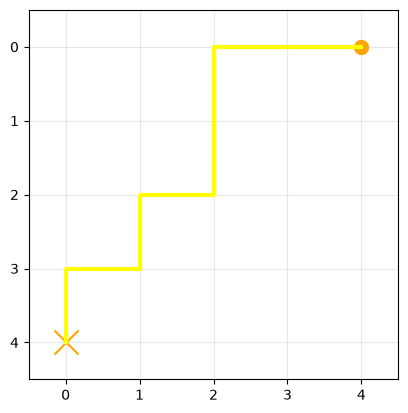

In [22]:
env.visualize_one_traj(min_salience_traj)

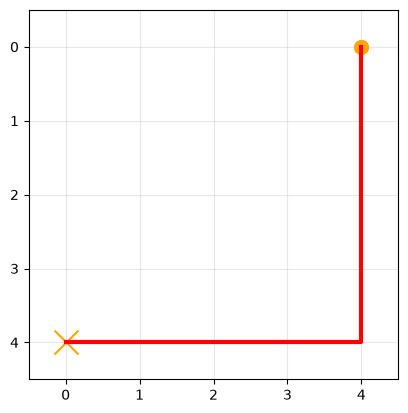

In [23]:
env.visualize_one_traj(max_salience_traj)

# sample similar + dissimilar trajectories
`TverskySimilarity` has `forward()` which returns the similarity of two trajs;
we can use this to reproduce figure 3 in SIRL - given query, sample 2 most similar and 2 least similar trajs

In [24]:
all_sim = model.encoder[0].similarity(centered_trajs, centered_trajs)
all_sim.shape

torch.Size([1960, 1960])

=== QUERY TRAJECTORY IDX {QUERY_TRAJ_IDX}===


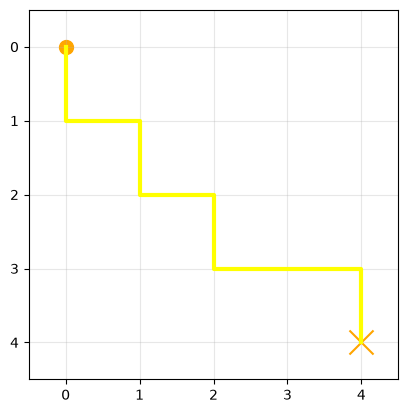

=== MOST SIMILAR: ===


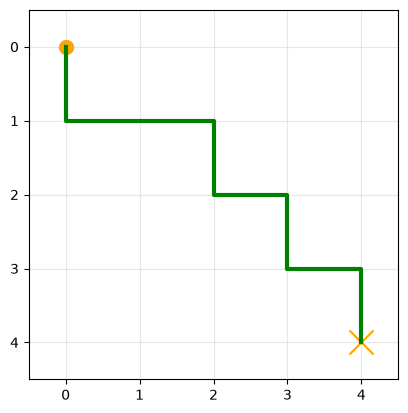

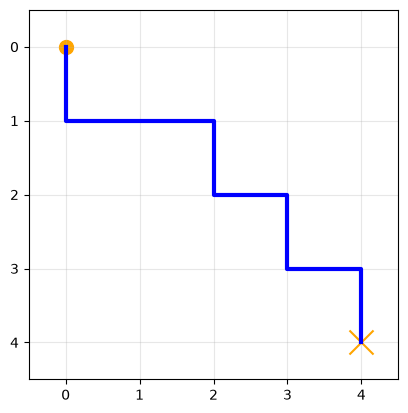

=== LEAST SIMILAR: ===


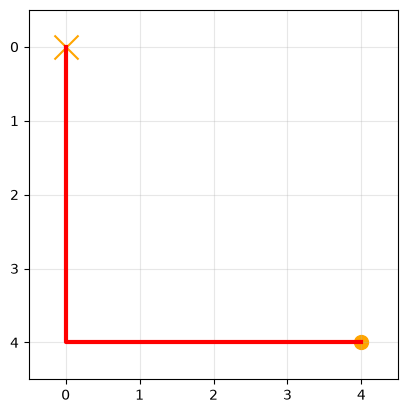

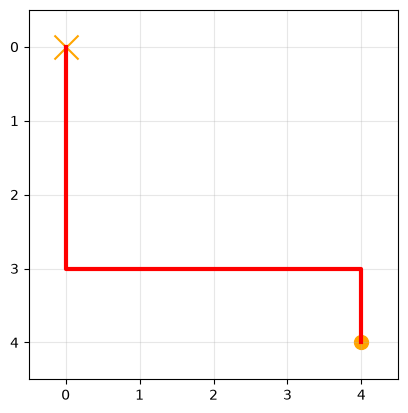

In [25]:
# RERUN THIS CELL FOR RANDOM QUERY
import random

QUERY_TRAJ_IDX = random.randint(0, len(all_trajs) - 1)
TOP_N = 2

query_embed = centered_trajs[QUERY_TRAJ_IDX].detach().unsqueeze(0)
query_sim = all_sim.detach().numpy()[QUERY_TRAJ_IDX]
indices_sorted_by_similarity = np.argsort(query_sim)
least_similar = indices_sorted_by_similarity[:TOP_N] # starts with negative similarity, since sort is ascending
most_similar = indices_sorted_by_similarity[-TOP_N:]

query_traj = all_trajs[QUERY_TRAJ_IDX]
print("=== QUERY TRAJECTORY IDX {QUERY_TRAJ_IDX}===")
env.visualize_one_traj(query_traj)
print("=== MOST SIMILAR: ===")
for i in most_similar:
    env.visualize_one_traj(all_trajs[i])
print("=== LEAST SIMILAR: ===")
for i in least_similar:
    env.visualize_one_traj(all_trajs[i])

# sort trajectories by salience

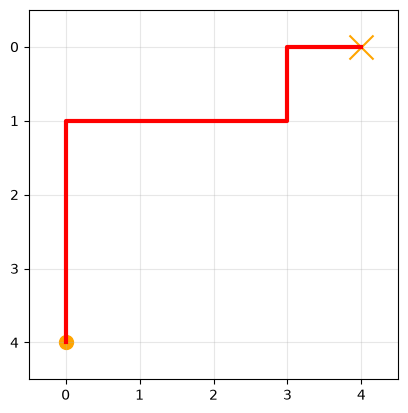

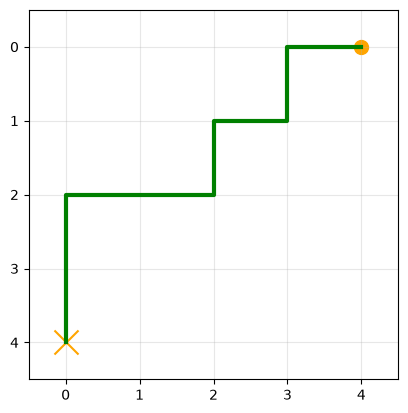

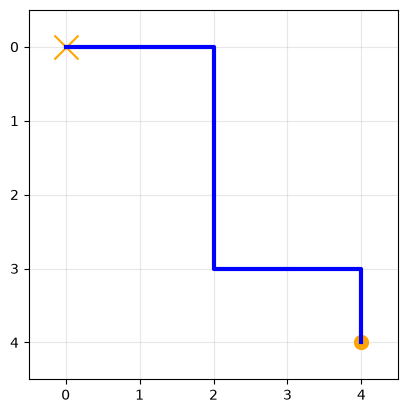

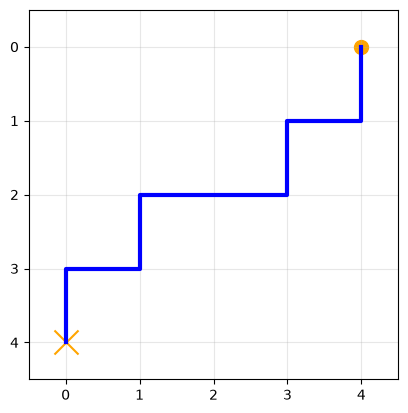

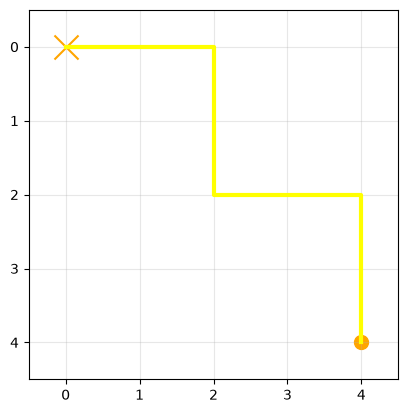

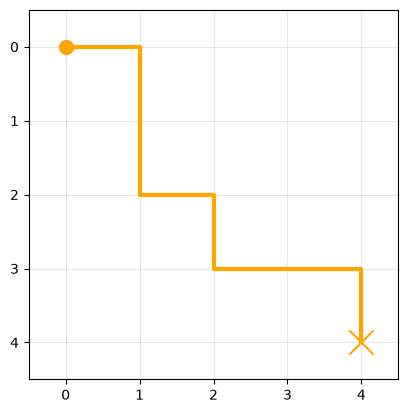

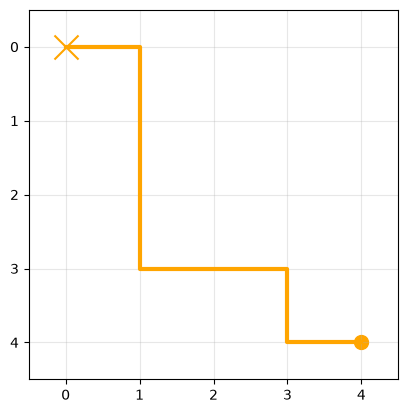

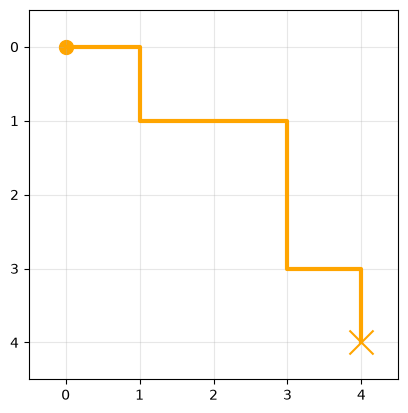

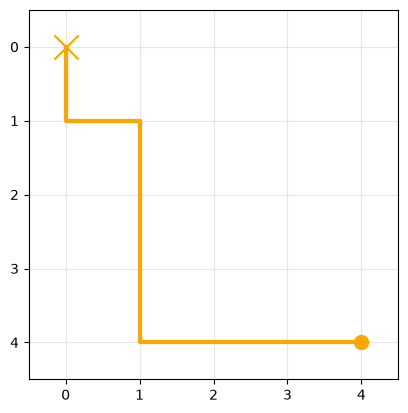

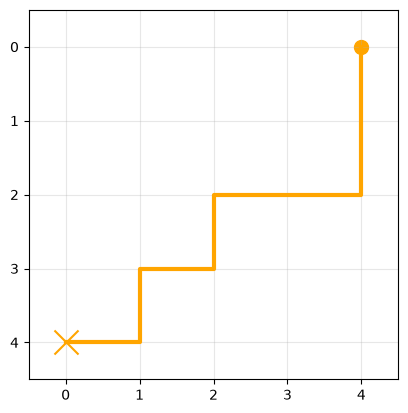

In [26]:
# SORT_BY_SALIENCE
# visualize SAMPLE_N least -> most salient trajs
sorted_salience_idxs = centered_salience.argsort()
SAMPLE_N = 10
sampled_salience_idxs = [i for i in range(0, len(sorted_salience_idxs), len(sorted_salience_idxs) // SAMPLE_N)]
for i in sorted_salience_idxs[sampled_salience_idxs]:
    env.visualize_one_traj(all_trajs[i])

# max feature value - min feature value t-test of means

In [27]:
# from tversky-networks-iclr2026/experiments/103-vision-nabirds/src/semantic_utils.py
def retrieve_semantic_expression(
    instance_vectors: torch.Tensor,   # (N, D)  — all instance reps from parquet
    feature_bank: torch.Tensor,        # (F, D)  — from .npy
    expression: str,
    top_feature_count: int,
    top_result_count: int,
) -> dict:
    """
    Evaluate a set expression over instance vectors and feature bank.
    Expression uses s(i) notation where i is a dataset item_id (row index).
    Example: "s(0) - s(1)"  →  features of item 0 minus features of item 1
    """
    query_item_ixes = []

    def s(item_ix: int) -> set:
        feature_values = instance_vectors[item_ix:item_ix+1] @ feature_bank.T  # (1, F)
        print(f"{item_ix} feature_values")
        print(feature_values)
        feature_ixes = []
        for feature_ix in torch.argsort(feature_values[0], descending=True)[:top_feature_count]:
            # print("loop")
            # print(feature_values[0][feature_ix])
            if feature_values[0][feature_ix] > 0:
                feature_ixes.append(int(feature_ix))
            else:
                break
        query_item_ixes.append(item_ix)
        print(set(feature_ixes))
        return set(feature_ixes)

    semantic_features = eval(expression)

    if not semantic_features:
        print("Expression evaluated to empty feature set.")
        return {"expression": expression, "query_item_ixes": [], "top_instances": [], "feature_count": 0}

    semantic_f_bank = torch.index_select(
        feature_bank, 0, torch.tensor(sorted(semantic_features))
    )
    dot = instance_vectors @ semantic_f_bank.T          # (N, |features|)
    p_saliences = F.relu(dot).sum(dim=1)                # (N,)
    p_measures  = dot.sum(dim=1)                        # (N,)

    top_instances = []
    for result_ix in torch.argsort(p_measures, descending=True)[:top_result_count]:
        top_instances.append({
            "item_ix"  : result_ix.item(),
            "salience" : p_saliences[result_ix].item(),
            "measure"  : p_measures[result_ix].item(),
        })
    return {
        "expression"      : expression.strip(),
        "query_item_ixes" : query_item_ixes,
        "feature_count"   : len(semantic_features),
        "top_instances"   : top_instances,
    }

laptop max - min
29 feature_values
tensor([[4.0385, 6.2148, 4.3958, 4.0009]])
{0, 1, 2, 3}
1 feature_values
tensor([[-2.2198,  1.2457,  2.3289, -0.8100]])
{1, 2}


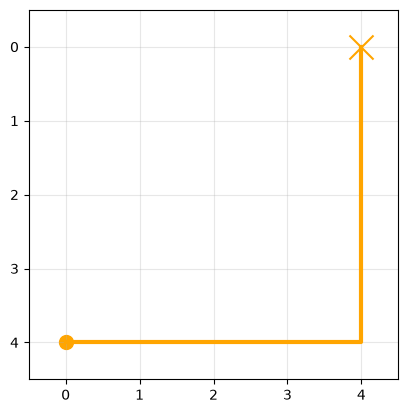

minus...


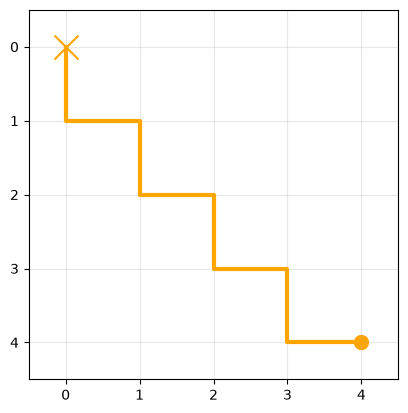

equals...


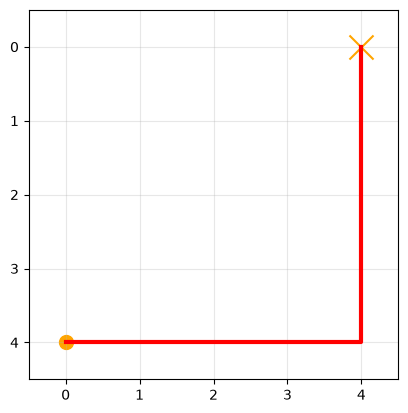

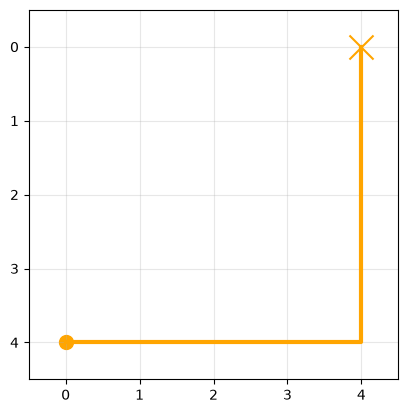

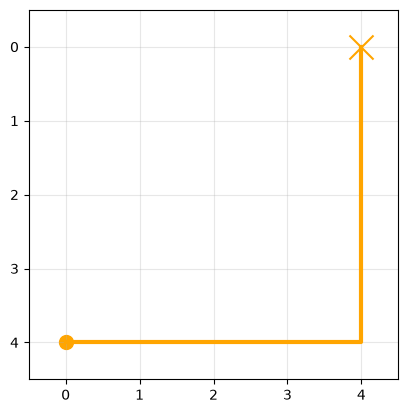

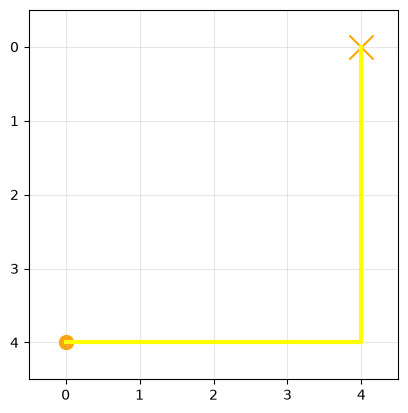

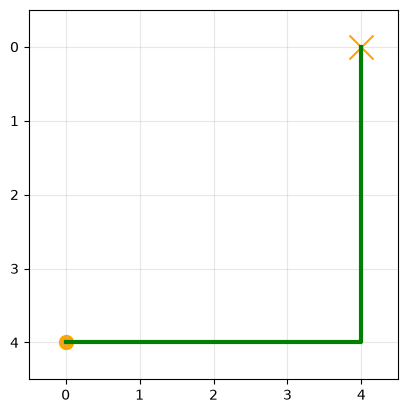

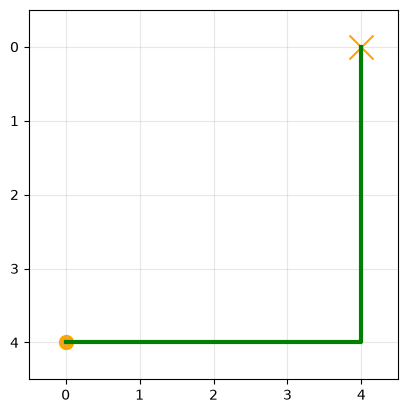

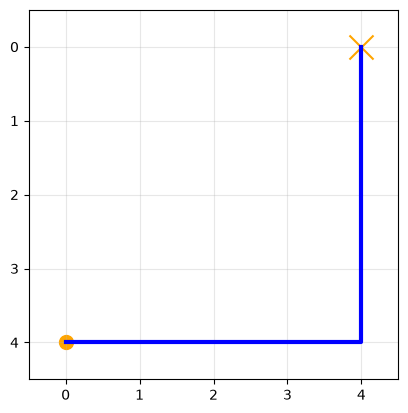

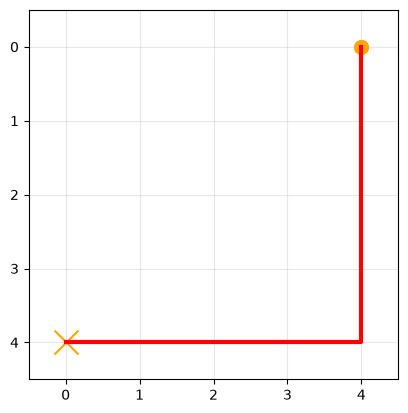

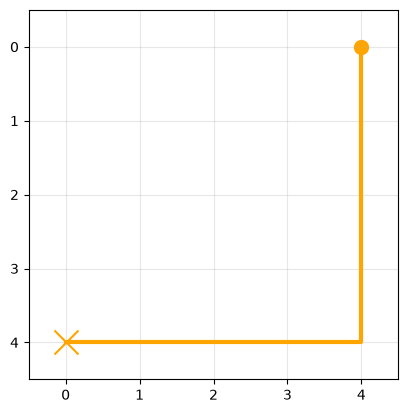

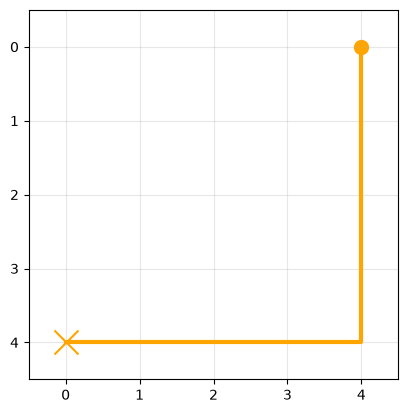

-----
laptop min - max
1 feature_values
tensor([[-2.2198,  1.2457,  2.3289, -0.8100]])
{1, 2}
29 feature_values
tensor([[4.0385, 6.2148, 4.3958, 4.0009]])
{0, 1, 2, 3}
Expression evaluated to empty feature set.


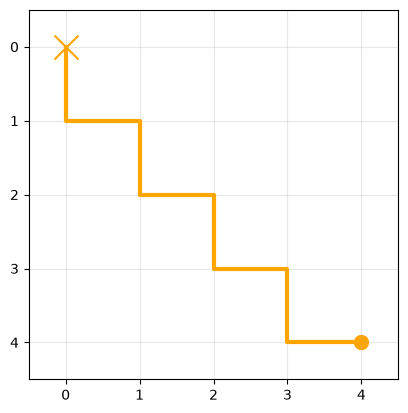

minus...


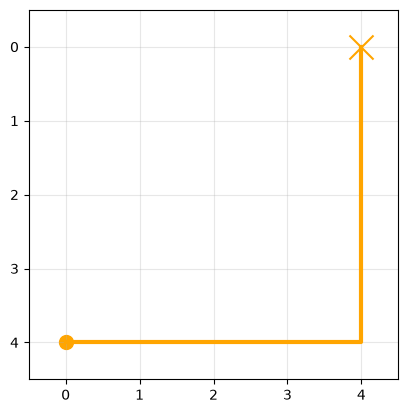

equals...
upright max - min
2 feature_values
tensor([[ 1.0311,  1.9523,  0.2150, -0.2105]])
{0, 1, 2}
3 feature_values
tensor([[ 2.0550, -0.8369, -3.3906,  0.9329]])
{0, 3}


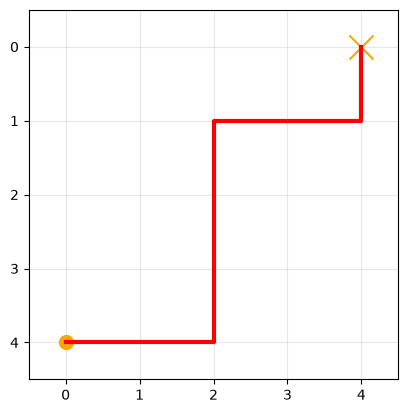

minus...


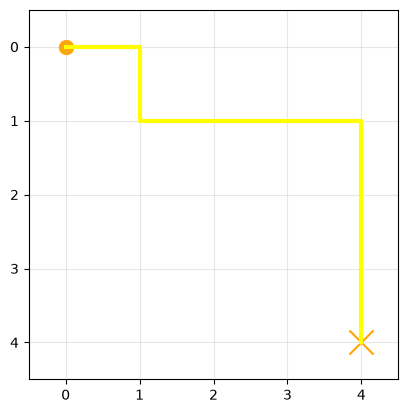

equals...


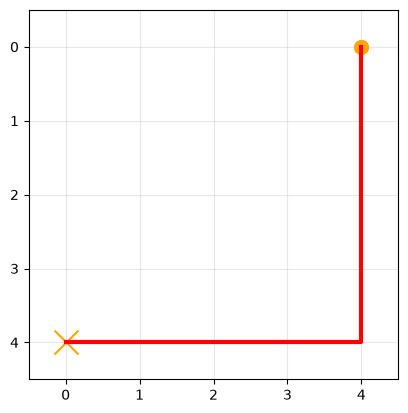

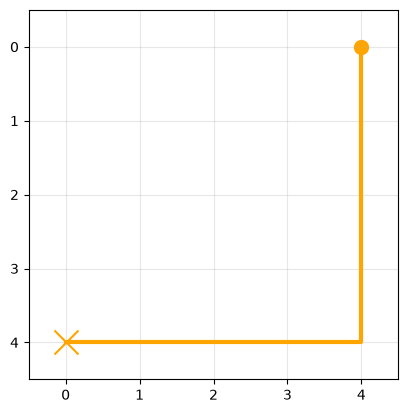

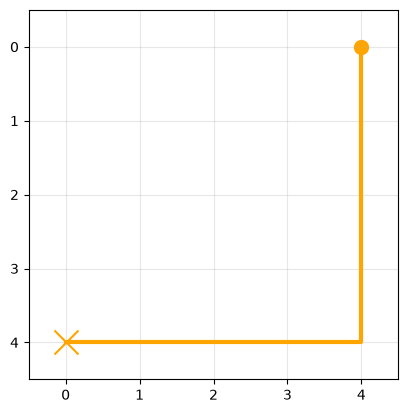

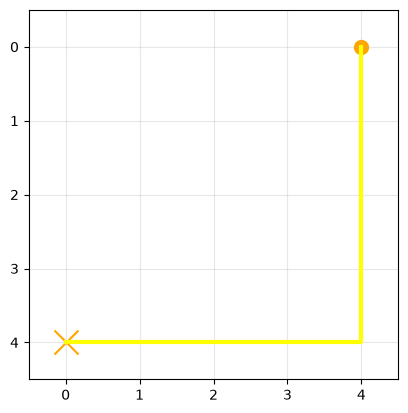

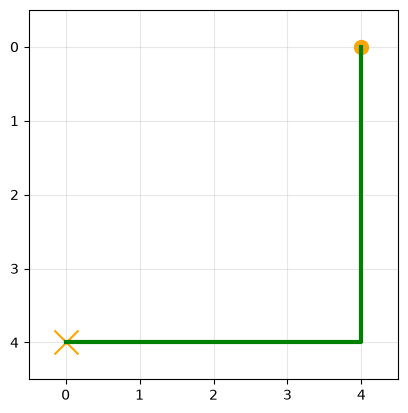

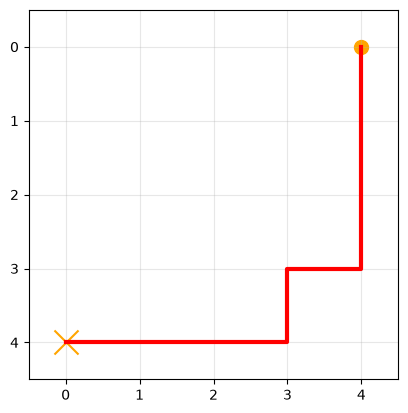

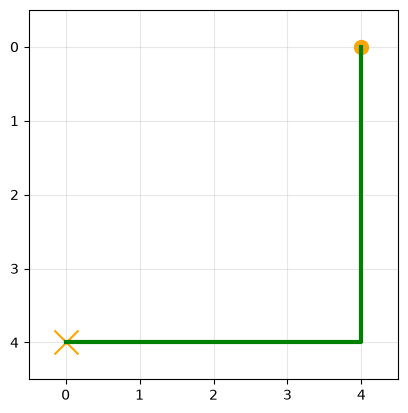

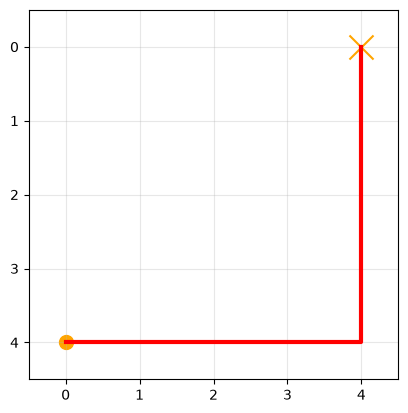

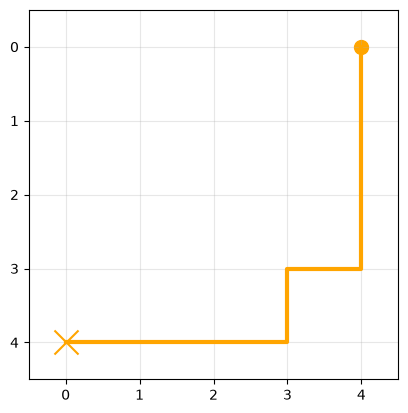

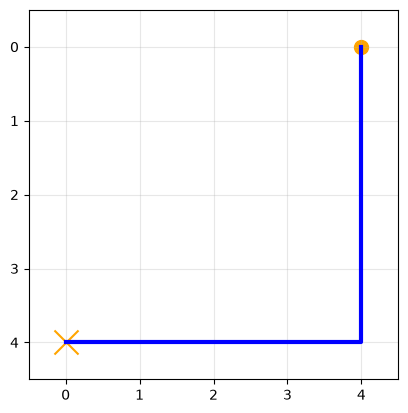

-----
upright min - max
3 feature_values
tensor([[ 2.0550, -0.8369, -3.3906,  0.9329]])
{0, 3}
2 feature_values
tensor([[ 1.0311,  1.9523,  0.2150, -0.2105]])
{0, 1, 2}


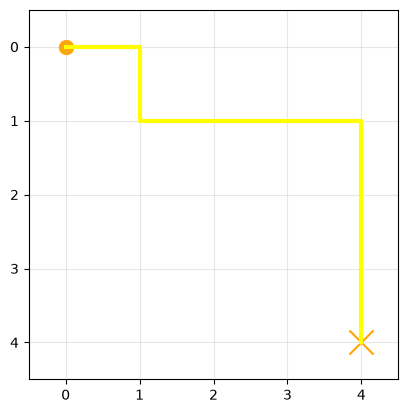

minus...


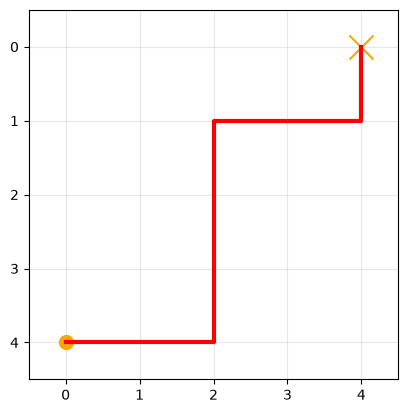

equals...


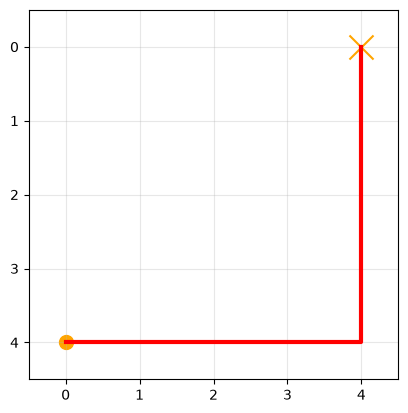

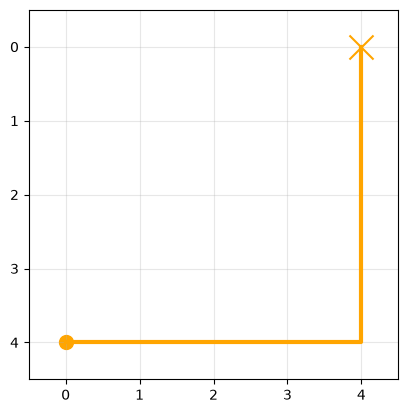

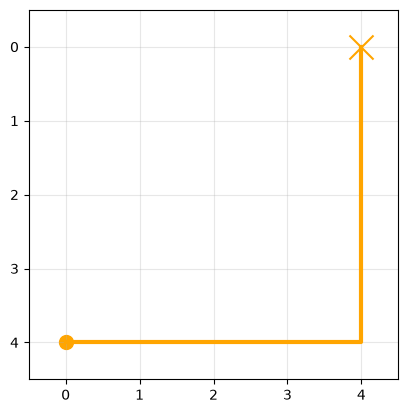

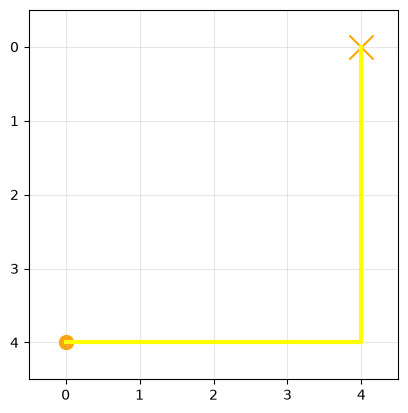

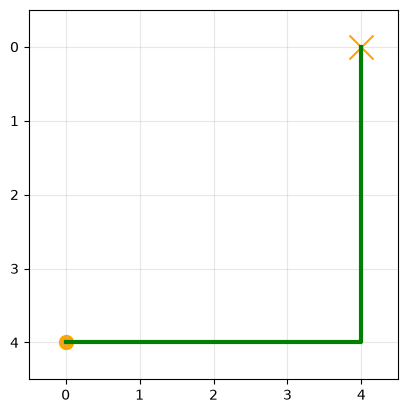

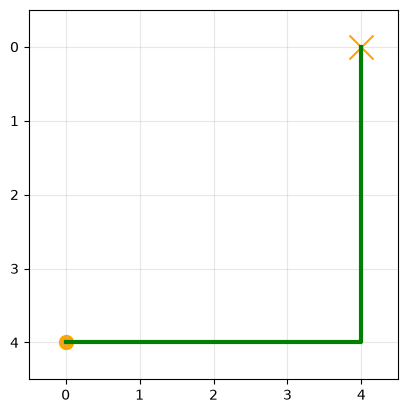

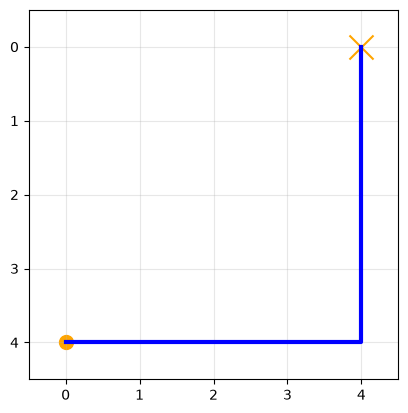

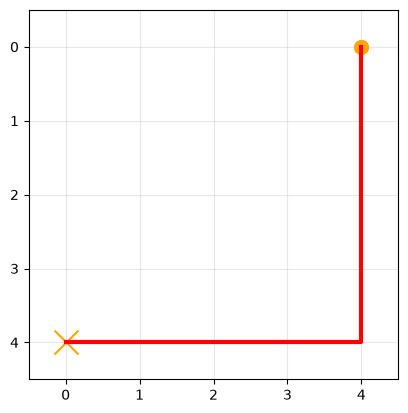

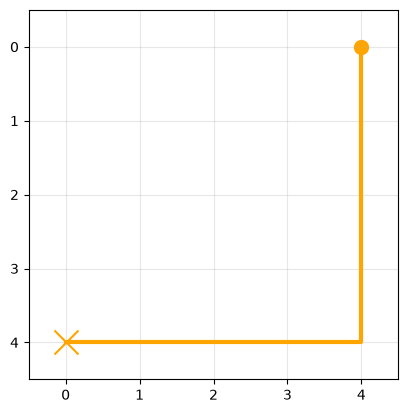

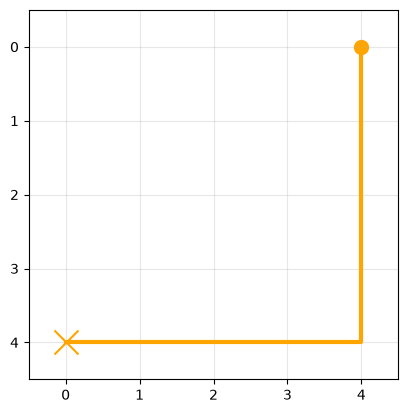

In [29]:
laptop_min_idx = np.argmin(all_feats[:,0])
laptop_max_idx= np.argmax(all_feats[:,0])
upright_min_idx = np.argmin(all_feats[:,1])
upright_max_idx = np.argmax(all_feats[:,1])

print("laptop max - min")
res = retrieve_semantic_expression(
    instance_vectors=centered_trajs, #(N, D)
    feature_bank=feature_bank, # (F, D)
    expression=f"s({laptop_max_idx})-s({laptop_min_idx})", 
    top_feature_count=4,
    top_result_count=10,
)
env.visualize_one_traj(all_trajs[laptop_max_idx])
print("minus...")
env.visualize_one_traj(all_trajs[laptop_min_idx])
print("equals...")
for instance in res["top_instances"]:
    idx = instance["item_ix"]
    env.visualize_one_traj(all_trajs[idx])

print("-----")
print("laptop min - max")
res = retrieve_semantic_expression(
    instance_vectors=centered_trajs, #(N, D)
    feature_bank=feature_bank, # (F, D)
    expression=f"s({laptop_min_idx})-s({laptop_max_idx})", 
    top_feature_count=4,
    top_result_count=10,
)
env.visualize_one_traj(all_trajs[laptop_min_idx])
print("minus...")
env.visualize_one_traj(all_trajs[laptop_max_idx])
print("equals...")
for instance in res["top_instances"]:
    idx = instance["item_ix"]
    env.visualize_one_traj(all_trajs[idx])

print("=========")

print("upright max - min")
res = retrieve_semantic_expression(
    instance_vectors=centered_trajs, #(N, D)
    feature_bank=feature_bank, # (F, D)
    expression=f"s({upright_max_idx})-s({upright_min_idx})", 
    top_feature_count=4,
    top_result_count=10,
)
env.visualize_one_traj(all_trajs[upright_max_idx])
print("minus...")
env.visualize_one_traj(all_trajs[upright_min_idx])
print("equals...")
for instance in res["top_instances"]:
    idx = instance["item_ix"]
    env.visualize_one_traj(all_trajs[idx])

print("-----")
print("upright min - max")
res = retrieve_semantic_expression(
    instance_vectors=centered_trajs, #(N, D)
    feature_bank=feature_bank, # (F, D)
    expression=f"s({upright_min_idx})-s({upright_max_idx})", 
    top_feature_count=4,
    top_result_count=10,
)
env.visualize_one_traj(all_trajs[upright_min_idx])
print("minus...")
env.visualize_one_traj(all_trajs[upright_max_idx])
print("equals...")
for instance in res["top_instances"]:
    idx = instance["item_ix"]
    env.visualize_one_traj(all_trajs[idx])

## t-test of means - can't do it on this model because most of the feature sets are empty!

In [ ]:
# for reference...

# max_min_table_vals = []
# for instance in max_min_res["top_instances"]:
#     idx = instance["item_ix"]
#     max_min_table_vals.append(all_features[idx, 0])
# print(np.mean(max_min_table_vals))

# min_max_table_vals= []
# for instance in min_max_res["top_instances"]:
#     idx = instance["item_ix"]
#     min_max_table_vals.append(all_features[idx, 0])
# print(np.mean(min_max_table_vals))

# from scipy import stats
# stats.ttest_ind(max_min_table_vals, min_max_table_vals)

- [ ] like CLRvis - train BT preference model with semantic expressions: given a pair of (preferred, dispreferred), get preferred set (pref - dispref) and dispreferred set (dispref - pref) and use these as all-pairs preference comparisons
	- except we use e.g table value as "preference"
	- test how many queries we need to get accuracy comparable to training a classifier? or comparable to regular bradley terry pairwise comparisons
	- measure accuracy on true pairs (test set)
	- *we are teaching features the same way as rewards*